In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score

import json
import csv
import os

In [53]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [55]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [56]:
train_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

In [57]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [58]:
num_classes = len(train_dataset.dataset.classes)
print("num_classes:", num_classes)

num_classes: 47


In [59]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [60]:
x, y = next(iter(train_loader))

print("x shape:", x.shape)
print("y shape:", y.shape)

print("min:", x.min().item(), "max:", x.max().item())

x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
min: 0.0 max: 1.0


In [61]:
class MLP(nn.Module):

    def __init__(self, hidden=[256,128], dropout=0.0, batchnorm=False, num_classes=10):
        super().__init__()

        layers = []
        input_size = 28*28

        for h in hidden:

            layers.append(nn.Linear(input_size, h))

            if batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            input_size = h

        layers.append(nn.Linear(input_size, num_classes))

        self.model = nn.Sequential(
            nn.Flatten(),
            *layers
        )

    def forward(self, x):
        return self.model(x)

In [62]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    preds = []
    targets = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds.extend(torch.argmax(logits,1).cpu().numpy())
        targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)

    return total_loss/len(loader), acc

In [63]:
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            total_loss += loss.item()

            preds.extend(torch.argmax(logits,1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)

    return total_loss/len(loader), acc

In [64]:
def train_model(model, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss":[],
        "val_loss":[],
        "train_acc":[],
        "val_acc":[]
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(epoch, train_loss, val_loss, train_acc, val_acc)

    return history

In [65]:
model = MLP(
    hidden=[256,128],
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E1 = train_model(model, optimizer, epochs=10)

0 1.2908168968579448 0.8303357174167525 0.6371010638297873 0.7516400709219858
1 0.7008089156438273 0.6561364817754024 0.7806405141843972 0.7963209219858156
2 0.5697701393712497 0.5806426939654485 0.8138519503546099 0.8133421985815603
3 0.49909830317429615 0.5390192766984304 0.8335771276595745 0.8261081560283688
4 0.4534936599697627 0.5194176383274424 0.845667109929078 0.8322695035460993
5 0.4181859605912621 0.49489358774686265 0.8552859042553191 0.8414007092198581
6 0.3888719750634322 0.49680703541653304 0.8641843971631206 0.8373670212765958
7 0.367973323620803 0.49905835386723446 0.8688497340425532 0.8393617021276596
8 0.3435862753408175 0.49554108074829406 0.8753324468085106 0.8445921985815603
9 0.3269510527029105 0.5081392533361575 0.8800199468085106 0.8390070921985816


In [66]:
model = MLP(
    hidden=[256,128],
    dropout=0.3,
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E2 = train_model(model, optimizer, epochs=10)

0 1.555257687923756 0.8555447715150435 0.5551196808510638 0.7429964539007092
1 0.9412118635279068 0.6783221229321539 0.7114140070921986 0.7884751773049645
2 0.810215899453941 0.6109460713499684 0.7432291666666667 0.8061170212765958
3 0.7449001558283542 0.5689255480712416 0.7604942375886525 0.8150709219858157
4 0.7031315371922567 0.5435017727862643 0.7719082446808511 0.8235815602836879
5 0.6661417360846877 0.5247012912216833 0.7829233156028369 0.8280585106382978
6 0.6441600415723544 0.5074716614464582 0.7889849290780142 0.8352393617021276
7 0.6262311965438491 0.5043423962121629 0.7920656028368794 0.830540780141844
8 0.6082915664987362 0.4940436465592034 0.7976728723404255 0.8373670212765958
9 0.5964356022100922 0.48184197619136443 0.8011081560283688 0.8384751773049646


In [67]:
model = MLP(
    hidden=[256,128],
    batchnorm=True,
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E3 = train_model(model, optimizer, epochs=10)

0 0.9910671400262955 0.6066629389921824 0.7313386524822695 0.8089539007092199
1 0.5294153894515747 0.5261637113862119 0.8254543439716312 0.8250886524822695
2 0.45233109468686666 0.48577937298575363 0.8442043439716312 0.8389184397163121
3 0.40280110552801307 0.4707469492308838 0.8594525709219858 0.8435283687943262
4 0.36805212231392553 0.46248246855654956 0.869104609929078 0.84552304964539
5 0.3436713341068714 0.45676212071698935 0.874501329787234 0.850531914893617
6 0.32134323944436743 0.4652025521138294 0.8816821808510639 0.8481382978723404
7 0.3043667770446615 0.463538669681145 0.8858156028368794 0.8476063829787234
8 0.28834561549179943 0.46686718760237184 0.8909131205673759 0.8483156028368795
9 0.2711400644364932 0.48314133370663487 0.8966866134751773 0.8411347517730496


In [68]:
best_history = history_E2
best_config = {"dropout":0.3, "batchnorm":False}

if max(history_E3["val_acc"]) > max(history_E2["val_acc"]):
    best_history = history_E3
    best_config = {"dropout":0.0, "batchnorm":True}

In [69]:
class EarlyStopping:

    def __init__(self, patience=4):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return False

        self.counter += 1

        return self.counter >= self.patience

In [70]:
model = MLP(
    hidden=[256,128],
    dropout=best_config["dropout"],
    batchnorm=best_config["batchnorm"],
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

stopper = EarlyStopping(patience=4)

history_E4 = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(20):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion
    )

    history_E4["train_loss"].append(train_loss)
    history_E4["val_loss"].append(val_loss)
    history_E4["train_acc"].append(train_acc)
    history_E4["val_acc"].append(val_acc)

    if stopper.step(val_loss):
        break

In [71]:
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion
)

print("Test accuracy:", test_acc)

Test accuracy: 0.8400531914893618


In [72]:
model = MLP(
    hidden=[256,128],
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-1)

history_O1 = train_model(model, optimizer, epochs=6)

0 3.944938900792007 3.6015494651040116 0.04835992907801418 0.057624113475177305
1 3.529896852817941 3.5902960313915533 0.05451019503546099 0.058909574468085105
2 3.5246807098388673 3.4974276871330994 0.054598847517730496 0.05979609929078014
3 3.5087784168568064 3.5019007375684836 0.053701241134751776 0.06108156028368794
4 3.4967900002256354 3.5261429393358825 0.05527482269503546 0.04995567375886525
5 3.527586615677421 3.549808583017123 0.05288120567375887 0.05390070921985816


In [73]:
model = MLP(
    hidden=[256,128],
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

history_O2 = train_model(model, optimizer, epochs=6)

0 3.7845839473372656 3.671603994854426 0.10734707446808511 0.1901595744680851
1 3.4741082333503885 3.248923990012562 0.26207890070921985 0.3316489361702128
2 3.0036461914684756 2.764737170968352 0.3795988475177305 0.4251329787234043
3 2.5575013008523495 2.370962563207594 0.45612810283687943 0.4734042553191489
4 2.225232579353008 2.0959565417241244 0.49461436170212764 0.5095744680851064
5 1.9972774552960768 1.9087272424482356 0.522229609929078 0.5322251773049645


In [74]:
model = MLP(
    hidden=[256,128],
    num_classes=num_classes
).to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

history_O3 = train_model(model, optimizer, epochs=12)

0 2.1363193789272445 1.237716524951202 0.44260859929078017 0.6495567375886525
1 1.0671947612830088 0.934732055933462 0.6877216312056738 0.7249556737588653
2 0.8276960680670772 0.7699054220301956 0.7509308510638298 0.7655585106382978
3 0.7028911293398404 0.6833760019412822 0.7827460106382979 0.7901595744680852
4 0.6299070543431221 0.6448572045665676 0.8011857269503546 0.7995124113475177
5 0.5748328019963934 0.6145257781454398 0.8156360815602837 0.8060283687943263
6 0.5350840714383632 0.5720656271708213 0.8257535460992907 0.8218528368794327
7 0.5032811569406631 0.5503452856325161 0.8342531028368795 0.826950354609929
8 0.4788847528450878 0.531467736609238 0.8404033687943262 0.8285017730496453
9 0.457471878181958 0.514158390672867 0.8472739361702127 0.8327127659574468
10 0.43899112519220257 0.5120967155122488 0.8514738475177305 0.832491134751773
11 0.42194568104777774 0.5026003516326516 0.8559175531914893 0.8365248226950355


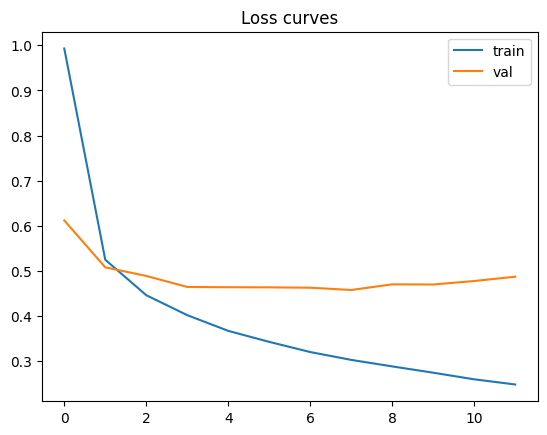

In [75]:
plt.plot(history_E4["train_loss"], label="train")
plt.plot(history_E4["val_loss"], label="val")

plt.legend()
plt.title("Loss curves")

plt.savefig("artifacts/figures/curves_best.png")

plt.show()

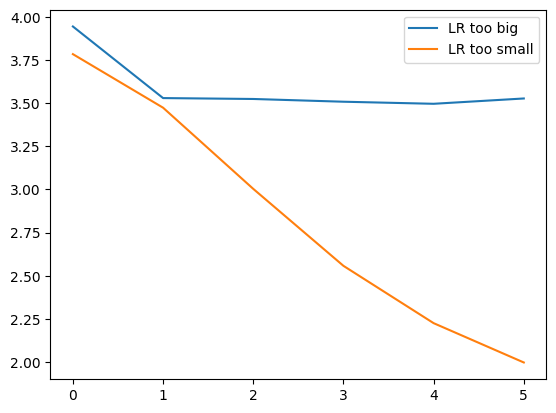

In [76]:
plt.plot(history_O1["train_loss"], label="LR too big")
plt.plot(history_O2["train_loss"], label="LR too small")

plt.legend()

plt.savefig("artifacts/figures/curves_lr_extremes.png")

plt.show()

In [77]:
torch.save(
    model.state_dict(),
    "artifacts/best_model.pt"
)

In [78]:
config = {
    "dataset":"EMNIST",
    "seed":SEED,
    "hidden":[256,128],
    "dropout":best_config["dropout"],
    "batchnorm":best_config["batchnorm"],
    "optimizer":"Adam",
    "lr":1e-3
}

with open("artifacts/best_config.json","w") as f:
    json.dump(config,f,indent=4)

In [79]:
import pandas as pd

runs = pd.DataFrame([
["E1","EMNIST",SEED,"256-128 relu", "Adam",1e-3,0,0,10,max(history_E1["val_acc"]),min(history_E1["val_loss"])],
["E2","EMNIST",SEED,"256-128 relu dropout=0.3", "Adam",1e-3,0,0,10,max(history_E2["val_acc"]),min(history_E2["val_loss"])],
["E3","EMNIST",SEED,"256-128 relu batchnorm", "Adam",1e-3,0,0,10,max(history_E3["val_acc"]),min(history_E3["val_loss"])],
["E4","EMNIST",SEED,"best + early stopping", "Adam",1e-3,0,0,len(history_E4["val_acc"]),max(history_E4["val_acc"]),min(history_E4["val_loss"])],
["O1","EMNIST",SEED,"same as E4","Adam",1e-1,0,0,6,max(history_O1["val_acc"]),min(history_O1["val_loss"])],
["O2","EMNIST",SEED,"same as E4","Adam",1e-5,0,0,6,max(history_O2["val_acc"]),min(history_O2["val_loss"])],
["O3","EMNIST",SEED,"same as E4","SGD",0.01,0.9,1e-4,12,max(history_O3["val_acc"]),min(history_O3["val_loss"])],
],
columns=[
"experiment_id",
"dataset",
"seed",
"model_summary",
"optimizer",
"lr",
"momentum",
"weight_decay",
"epochs_trained",
"best_val_accuracy",
"best_val_loss"
])

runs.to_csv("artifacts/runs.csv", index=False)